# 🧠 Multi-Class Sentiment Analysis System


Classes: Positive 😊 | Negative 😡 | Neutral 😐 | Mixed 🤔

In [1]:
!pip install nltk scikit-learn pandas matplotlib seaborn joblib -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, io, re, string, warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline

In [2]:
from google.colab import files
uploaded = files.upload()  # upload select dataset.csv

df = pd.read_csv('dataset.csv')
print(df['sentiment'].value_counts())
df.head(10)

Saving dataset.csv to dataset (1).csv
sentiment
Mixed       30
Positive    20
Negative    20
Neutral     20
Name: count, dtype: int64


,text,sentiment
0,I love this product so much!,Positive
1,"This is absolutely amazing, best purchase ever!",Positive
2,Fantastic service and great quality,Positive
3,"Really happy with the results, exceeded expect...",Positive
4,"Outstanding performance, highly recommend",Positive
5,"Best app I have ever used, very intuitive",Positive
6,"Great value for money, totally satisfied",Positive
7,Wonderful experience from start to finish,Positive
8,"Superb quality, arrived on time and works perf...",Positive
9,Incredible features and smooth performance,Positive


In [3]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english')) - {'not','no','never','but','however'}

def clean_text(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

df['cleaned'] = df['text'].apply(clean_text)
df[['text','cleaned','sentiment']].head(5)

,text,cleaned,sentiment
0,I love this product so much!,love product much,Positive
1,"This is absolutely amazing, best purchase ever!",absolutely amazing best purchase ever,Positive
2,Fantastic service and great quality,fantastic service great quality,Positive
3,"Really happy with the results, exceeded expect...",really happy result exceeded expectation,Positive
4,"Outstanding performance, highly recommend",outstanding performance highly recommend,Positive


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    df['cleaned'], df['sentiment'], test_size=0.2, random_state=42, stratify=df['sentiment']
)

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,2), max_features=5000, sublinear_tf=True)),
    ('clf',   LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced', random_state=42))
])
pipeline.fit(X_train, y_train)
print("✅ Model trained!")

✅ Model trained!


Accuracy: 55.56%

              precision    recall  f1-score   support

       Mixed       0.67      1.00      0.80         6
    Negative       0.50      0.25      0.33         4
     Neutral       0.40      0.50      0.44         4
    Positive       0.50      0.25      0.33         4

    accuracy                           0.56        18
   macro avg       0.52      0.50      0.48        18
weighted avg       0.53      0.56      0.51        18



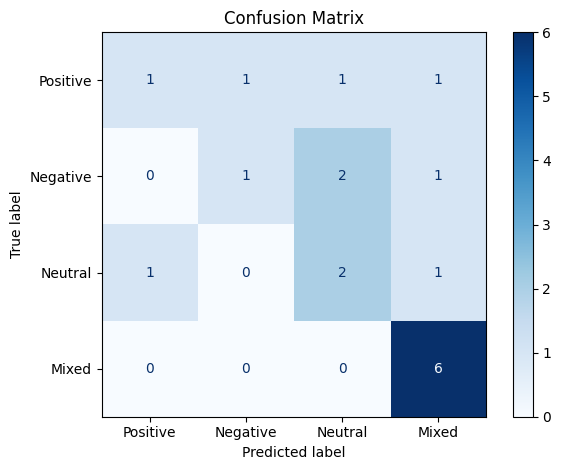

In [5]:
y_pred = pipeline.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=['Positive','Negative','Neutral','Mixed'])
disp = ConfusionMatrixDisplay(cm, display_labels=['Positive','Negative','Neutral','Mixed'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [6]:
joblib.dump(pipeline, 'sentiment_model.pkl')
print("✅ Model saved as sentiment_model.pkl")

✅ Model saved as sentiment_model.pkl


In [7]:
def predict(text):
    cleaned = clean_text(text)
    label = pipeline.predict([cleaned])[0]
    probs = dict(zip(pipeline.classes_, pipeline.predict_proba([cleaned])[0]))
    print(f"\nInput   : {text}")
    print(f"Result  : {label}")
    print("\nConfidence:")
    for k,v in sorted(probs.items(), key=lambda x: -x[1]):
        print(f"  {k:<10} {v*100:.1f}%")

predict("I love the design but hate the performance")
predict("This is absolutely amazing!")
predict("It is okay, nothing special")


Input   : I love the design but hate the performance
Result  : Mixed

Confidence:
  Mixed      42.7%
  Positive   23.4%
  Negative   17.1%
  Neutral    16.7%

Input   : This is absolutely amazing!
Result  : Positive

Confidence:
  Positive   39.5%
  Negative   22.6%
  Mixed      19.4%
  Neutral    18.6%

Input   : It is okay, nothing special
Result  : Neutral

Confidence:
  Neutral    42.6%
  Negative   19.9%
  Mixed      19.0%
  Positive   18.5%


In [8]:
sentences = [
    "Great product but terrible shipping",
    "Worst experience ever",
    "Works as expected",
    "Absolutely love it!"
]

results = []
for s in sentences:
    c = clean_text(s)
    label = pipeline.predict([c])[0]
    probs = dict(zip(pipeline.classes_, pipeline.predict_proba([c])[0]))
    results.append({'text': s, 'predicted': label, **{k: round(v,3) for k,v in probs.items()}})

df_results = pd.DataFrame(results)
df_results.to_csv('results.csv', index=False)
print(df_results)

                                  text predicted  Mixed  Negative  Neutral  \
0  Great product but terrible shipping     Mixed  0.378     0.217    0.217   
1                Worst experience ever  Negative  0.198     0.323    0.199   
2                    Works as expected   Neutral  0.190     0.227    0.295   
3                  Absolutely love it!  Positive  0.236     0.239    0.179   

   Positive  
0     0.188  
1     0.280  
2     0.288  
3     0.345  
